# Caterpillar vs. True Tree Comparison

For each sampled true tree and edge-length draw, computes $\Delta_{\mathbf{p}}(\text{caterpillar}, T^*)$ and the Robinson-Foulds (RF) distance between the closest caterpillar and $T^*$, then plots loss rate as a function of RF distance.

The caterpillar is selected by a depth-heuristic: leaves are ordered by a DFS that always visits the deepest subtree first, maximising the number of internal splits shared with $T^*$.

**Prerequisites**: precomputed NNI delta bundle from notebook 08.

In [ ]:
# ── Recompute flags ───────────────────────────────────────────────────────────
FORCE_RECOMPUTE_CATERPILLAR = False

# ── Analysis parameters ───────────────────────────────────────────────────────
N_LEAVES_LIST = [5, 6, 7, 8, 9]
N_TREES       = 500
ALPHA         = 0.20
BETA          = 0.01
N_SAMPLES     = 1000
SEED          = 42

# ── Output paths ──────────────────────────────────────────────────────────────
FIGURE_PATH = "../figures/Heuristic_caterpillar.pdf"

In [9]:
import sys
from pathlib import Path

import matplotlib as mpl
from matplotlib.backends.backend_pdf import PdfPages

cwd = Path.cwd().resolve()
src_candidates = [cwd / "src", cwd.parent / "src", cwd.parent.parent / "src"]
SRC_DIR = next((c for c in src_candidates if c.exists()), None)
if SRC_DIR is None:
    raise RuntimeError("Could not infer the src directory from the current working directory.")
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from inconsistency_generation.repo_paths import get_repo_root
from inconsistency_generation.nni_delta_precomputation import default_flip_weights
from inconsistency_generation.nni_margin_analysis import default_priors
from inconsistency_generation.caterpillar_analysis import (
    default_caterpillar_cache_path,
    load_or_compute_caterpillar_results,
)
from inconsistency_generation.nni_margin_plots import plot_caterpillar_win_vs_rf

REPO_ROOT = get_repo_root(cwd)
CACHE_DIR = REPO_ROOT / "cached_data"
FIGURES_DIR = REPO_ROOT / "figures"
CACHE_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

mpl.rcParams["figure.dpi"] = 150

In [10]:
W_P, W_N = default_flip_weights(ALPHA, BETA)
PRIORS = default_priors()

CATERPILLAR_CACHE_PATH = default_caterpillar_cache_path(
    cache_dir=CACHE_DIR, n_leaves_list=N_LEAVES_LIST, n_trees=N_TREES,
    n_samples=N_SAMPLES, alpha=ALPHA, beta=BETA, seed=SEED,
)
FIGURE_PATH = FIGURES_DIR / FIGURE_PATH

print(f"alpha={ALPHA}, beta={BETA}, w_P={W_P:.3f}, w_N={W_N:.3f}")
print(f"Caterpillar cache: {CATERPILLAR_CACHE_PATH.name}")

alpha=0.2, beta=0.01, w_P=1.599, w_N=4.382
Caterpillar cache: caterpillar_results_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl


## Compute caterpillar margins

In [11]:
caterpillar_dfs = load_or_compute_caterpillar_results(
    n_leaves_list=N_LEAVES_LIST,
    n_trees=N_TREES,
    priors=PRIORS,
    n_samples=N_SAMPLES,
    alpha=ALPHA,
    beta=BETA,
    w_pos=W_P,
    w_neg=W_N,
    seed=SEED,
    cache_path=CATERPILLAR_CACHE_PATH,
    force=FORCE_RECOMPUTE_CATERPILLAR,
)

Loaded caterpillar results from caterpillar_results_n5-6-7-8-9_trees500_samples1000_a0.200_b0.010_seed42.pkl


## Plot

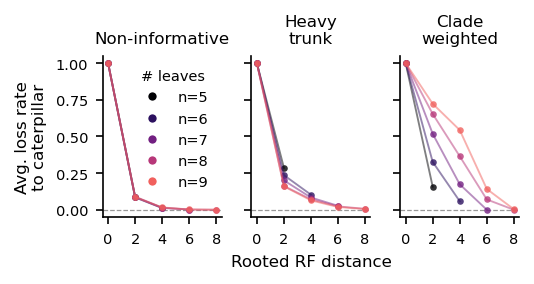

In [12]:
plot_caterpillar_win_vs_rf(caterpillar_dfs, N_LEAVES_LIST)

In [13]:
with PdfPages(FIGURE_PATH) as pdf:
    plot_caterpillar_win_vs_rf(caterpillar_dfs, N_LEAVES_LIST, pdf=pdf, show=False)
print(f"Saved {FIGURE_PATH}")

Saved /Users/satasg/Documents/repos/inconsistency_repo/figures/../figures/13_caterpillar_win_vs_rf.pdf
